In [1]:
import pandas as pd

# Load cleaned data
df = pd.read_csv("../data/processed/hdfc_top100_clean.csv")

# Show first 5 rows
df.head()

,date,nav
0,2013-11-18,13.0894
1,2013-11-19,13.1068
2,2013-11-20,12.9549
3,2013-11-21,12.7957
4,2013-11-22,12.7775


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3105 entries, 0 to 3104
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    3105 non-null   str    
 1   nav     3105 non-null   float64
dtypes: float64(1), str(1)
memory usage: 79.0 KB


In [3]:
df["date"] = pd.to_datetime(df["date"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3105 entries, 0 to 3104
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    3105 non-null   datetime64[us]
 1   nav     3105 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 48.6 KB


In [4]:
df.describe()

,date,nav
count,3105,3105.000000
mean,2020-03-10 18:11:42.608695,90.417733
min,2013-11-18 00:00:00,12.777500
25%,2017-01-17 00:00:00,40.297300
50%,2020-03-16 00:00:00,61.554800
75%,2023-05-08 00:00:00,130.847700
max,2026-06-19 00:00:00,214.676700
std,NaN,60.621453


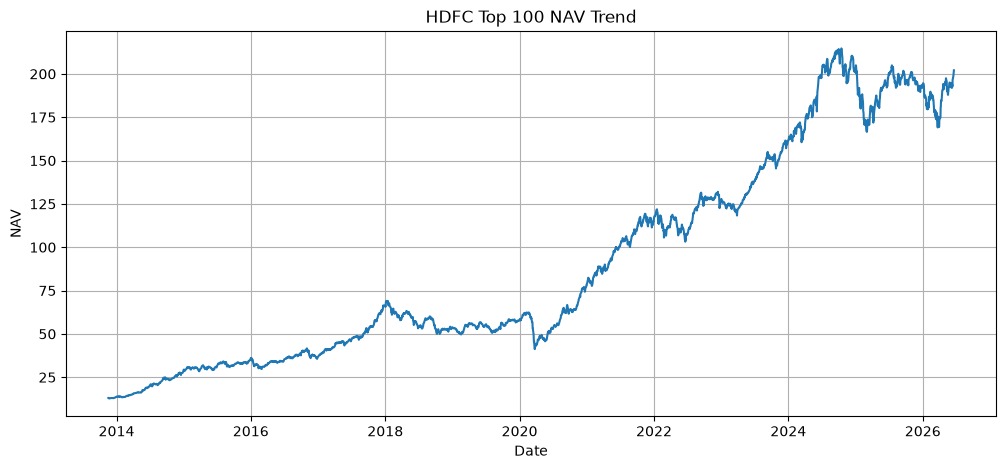

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df["date"], df["nav"])
plt.title("HDFC Top 100 NAV Trend")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.grid(True)
plt.show()

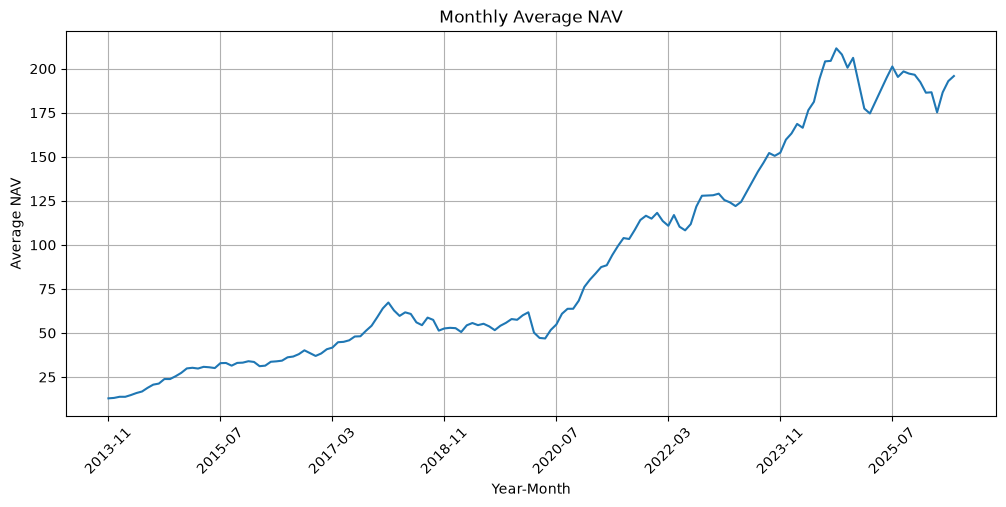

In [6]:
# Create year-month column
df["YearMonth"] = df["date"].dt.to_period("M").astype(str)

# Calculate monthly average NAV
monthly_nav = df.groupby("YearMonth")["nav"].mean()

# Plot monthly average NAV
plt.figure(figsize=(12,5))
monthly_nav.plot()
plt.title("Monthly Average NAV")
plt.xlabel("Year-Month")
plt.ylabel("Average NAV")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

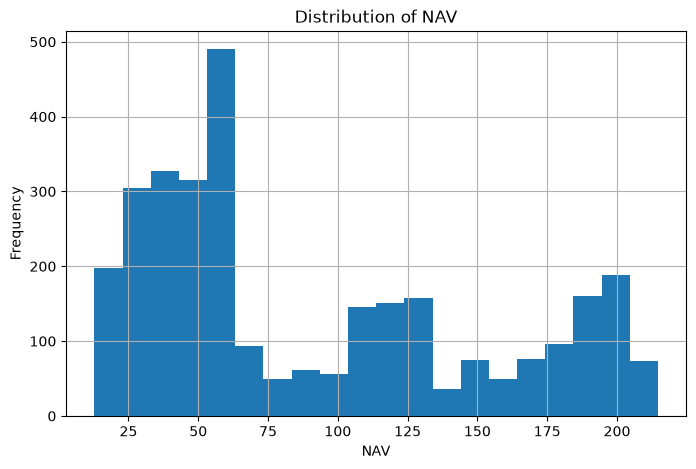

In [7]:
plt.figure(figsize=(8,5))
plt.hist(df["nav"], bins=20)
plt.title("Distribution of NAV")
plt.xlabel("NAV")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

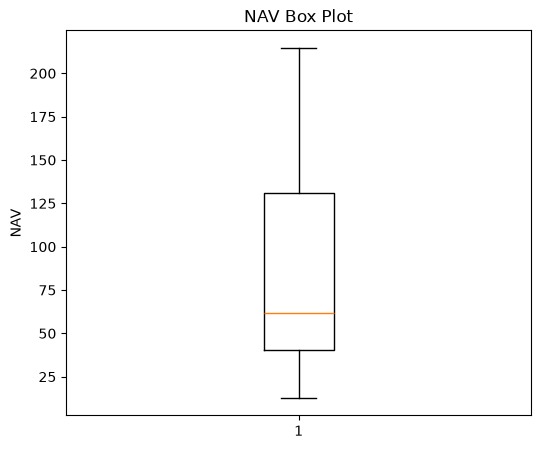

In [8]:
plt.figure(figsize=(6,5))
plt.boxplot(df["nav"])
plt.title("NAV Box Plot")
plt.ylabel("NAV")
plt.show()

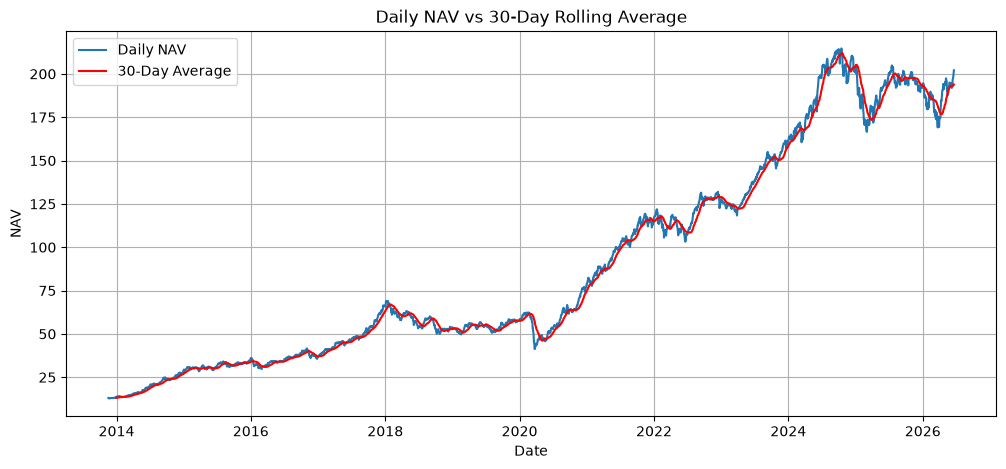

In [9]:
df["Rolling_30"] = df["nav"].rolling(30).mean()

plt.figure(figsize=(12,5))
plt.plot(df["date"], df["nav"], label="Daily NAV")
plt.plot(df["date"], df["Rolling_30"], color="red", label="30-Day Average")
plt.title("Daily NAV vs 30-Day Rolling Average")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()
plt.grid(True)
plt.show()

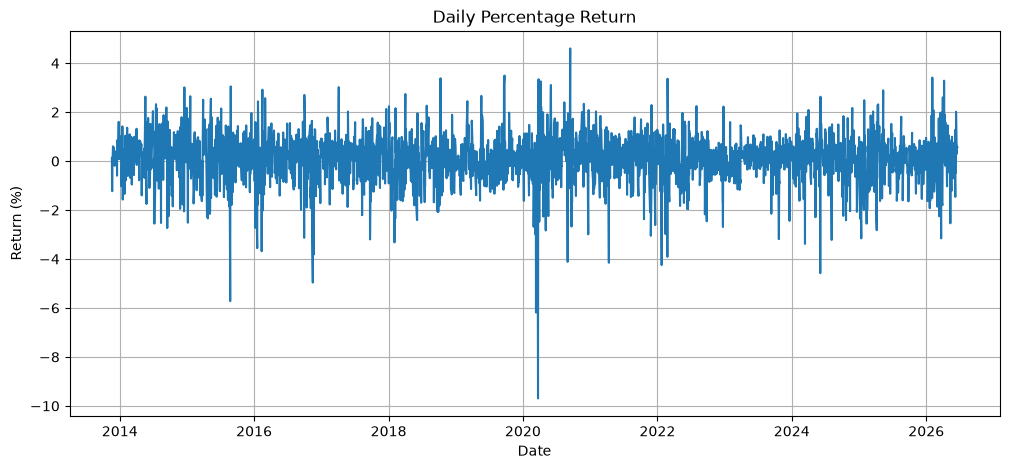

In [10]:
# Daily Percentage Return
df["Daily_Return"] = df["nav"].pct_change() * 100

plt.figure(figsize=(12,5))
plt.plot(df["date"], df["Daily_Return"])
plt.title("Daily Percentage Return")
plt.xlabel("Date")
plt.ylabel("Return (%)")
plt.grid(True)
plt.show()

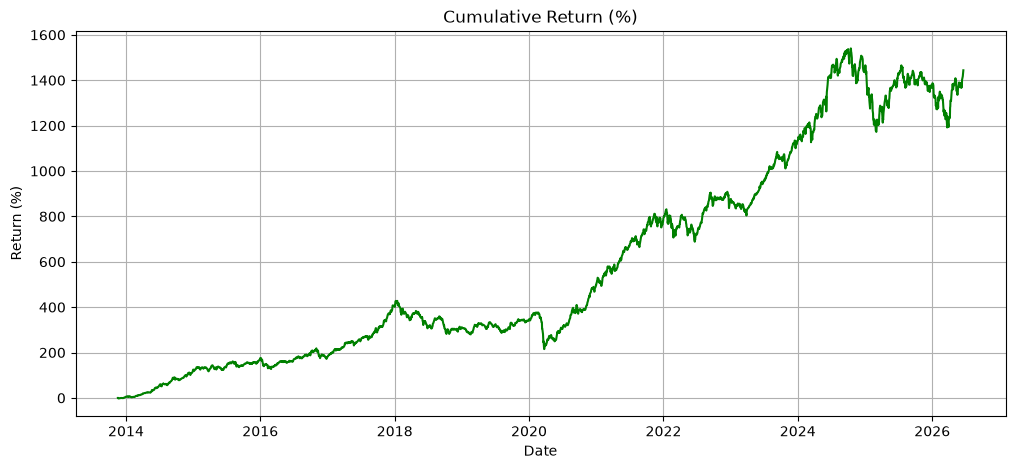

In [12]:
# Cumulative Return
df["Cumulative_Return"] = ((df["nav"] / df["nav"].iloc[0]) - 1) * 100

plt.figure(figsize=(12,5))
plt.plot(df["date"], df["Cumulative_Return"], color="green")
plt.title("Cumulative Return (%)")
plt.xlabel("Date")
plt.ylabel("Return (%)")
plt.grid(True)
plt.show()

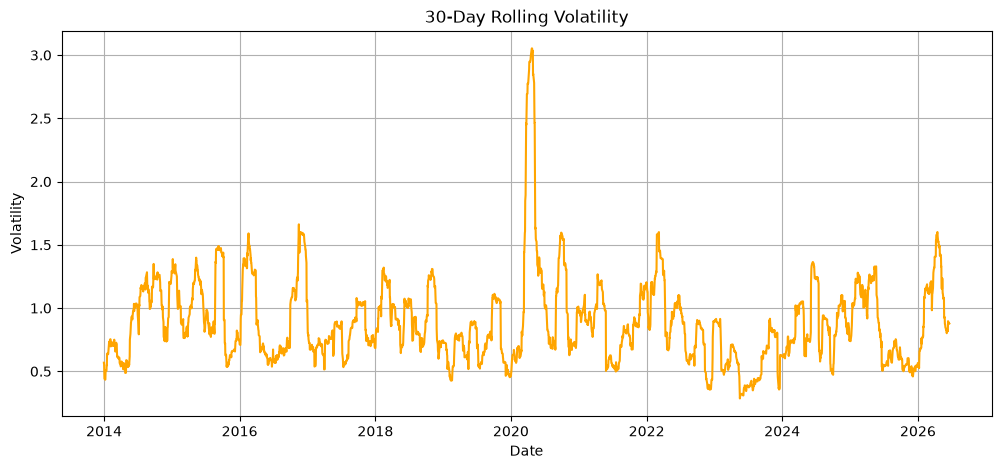

In [13]:
# 30-Day Rolling Volatility
df["Rolling_Volatility"] = df["Daily_Return"].rolling(30).std()

plt.figure(figsize=(12,5))
plt.plot(df["date"], df["Rolling_Volatility"], color="orange")
plt.title("30-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.grid(True)
plt.show()

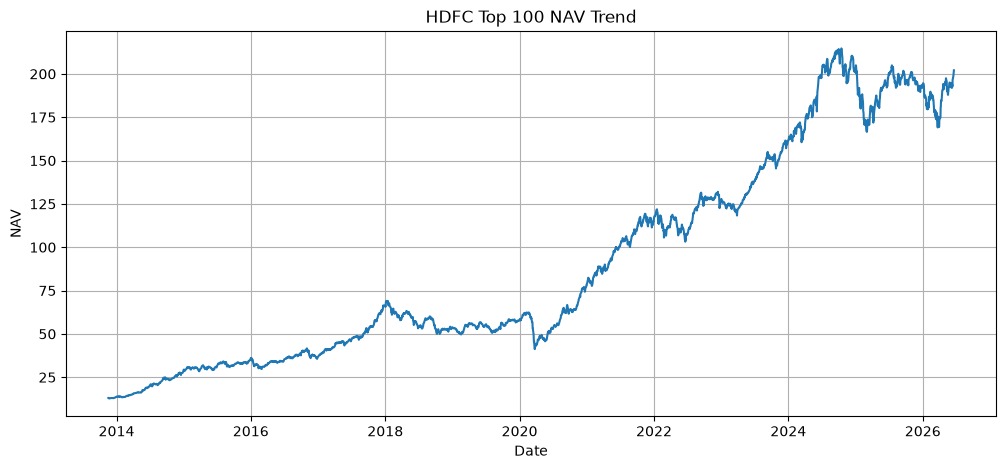

In [14]:
plt.figure(figsize=(12,5))
plt.plot(df["date"], df["nav"])
plt.title("HDFC Top 100 NAV Trend")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.grid(True)

plt.savefig("../reports/charts/nav_trend.png", dpi=300, bbox_inches="tight")

plt.show()